In [1]:
from ultralytics import YOLO, settings
import os
import shutil
from IPython.display import Image, display

# Configurar pasta de saída local (para não salvar em /root/.config)
settings.update({'runs_dir': './runs'})

# Verificar se tem GPU (opcional, mas bom saber)
import torch
print(f"CUDA disponível? {torch.cuda.is_available()}")

CUDA disponível? True


In [2]:
# Defina aqui o caminho para o SEU arquivo data.yaml
# Opções comuns: 'dataset_aquarium/data.yaml' ou 'dataset_construction/data.yaml'

dataset_path = '../dataset_onepiece/data.yaml'  # <--- EDITE AQUI se estiver usando outro

if not os.path.exists(dataset_path):
    print(f"⚠️ ATENÇÃO: Arquivo '{dataset_path}' não encontrado. Verifique o caminho!")
else:
    print(f"✅ Dataset encontrado: {dataset_path}")

✅ Dataset encontrado: ../dataset_onepiece/data.yaml


In [3]:
# Carregar modelo pré-treinado
model = YOLO('yolov8n.pt')

# Iniciar treinamento
# Os resultados serão salvos em runs/detect/trainX
results = model.train(data=dataset_path, epochs=10, imgsz=416, batch=8)

New https://pypi.org/project/ultralytics/8.4.55 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.51  Python-3.13.7 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 3060, 8192MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../dataset_onepiece/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0

Resultados salvos em: C:\Users\Disco\Desktop\projetos\visao\aula-09\notebooks\runs\detect\train-9


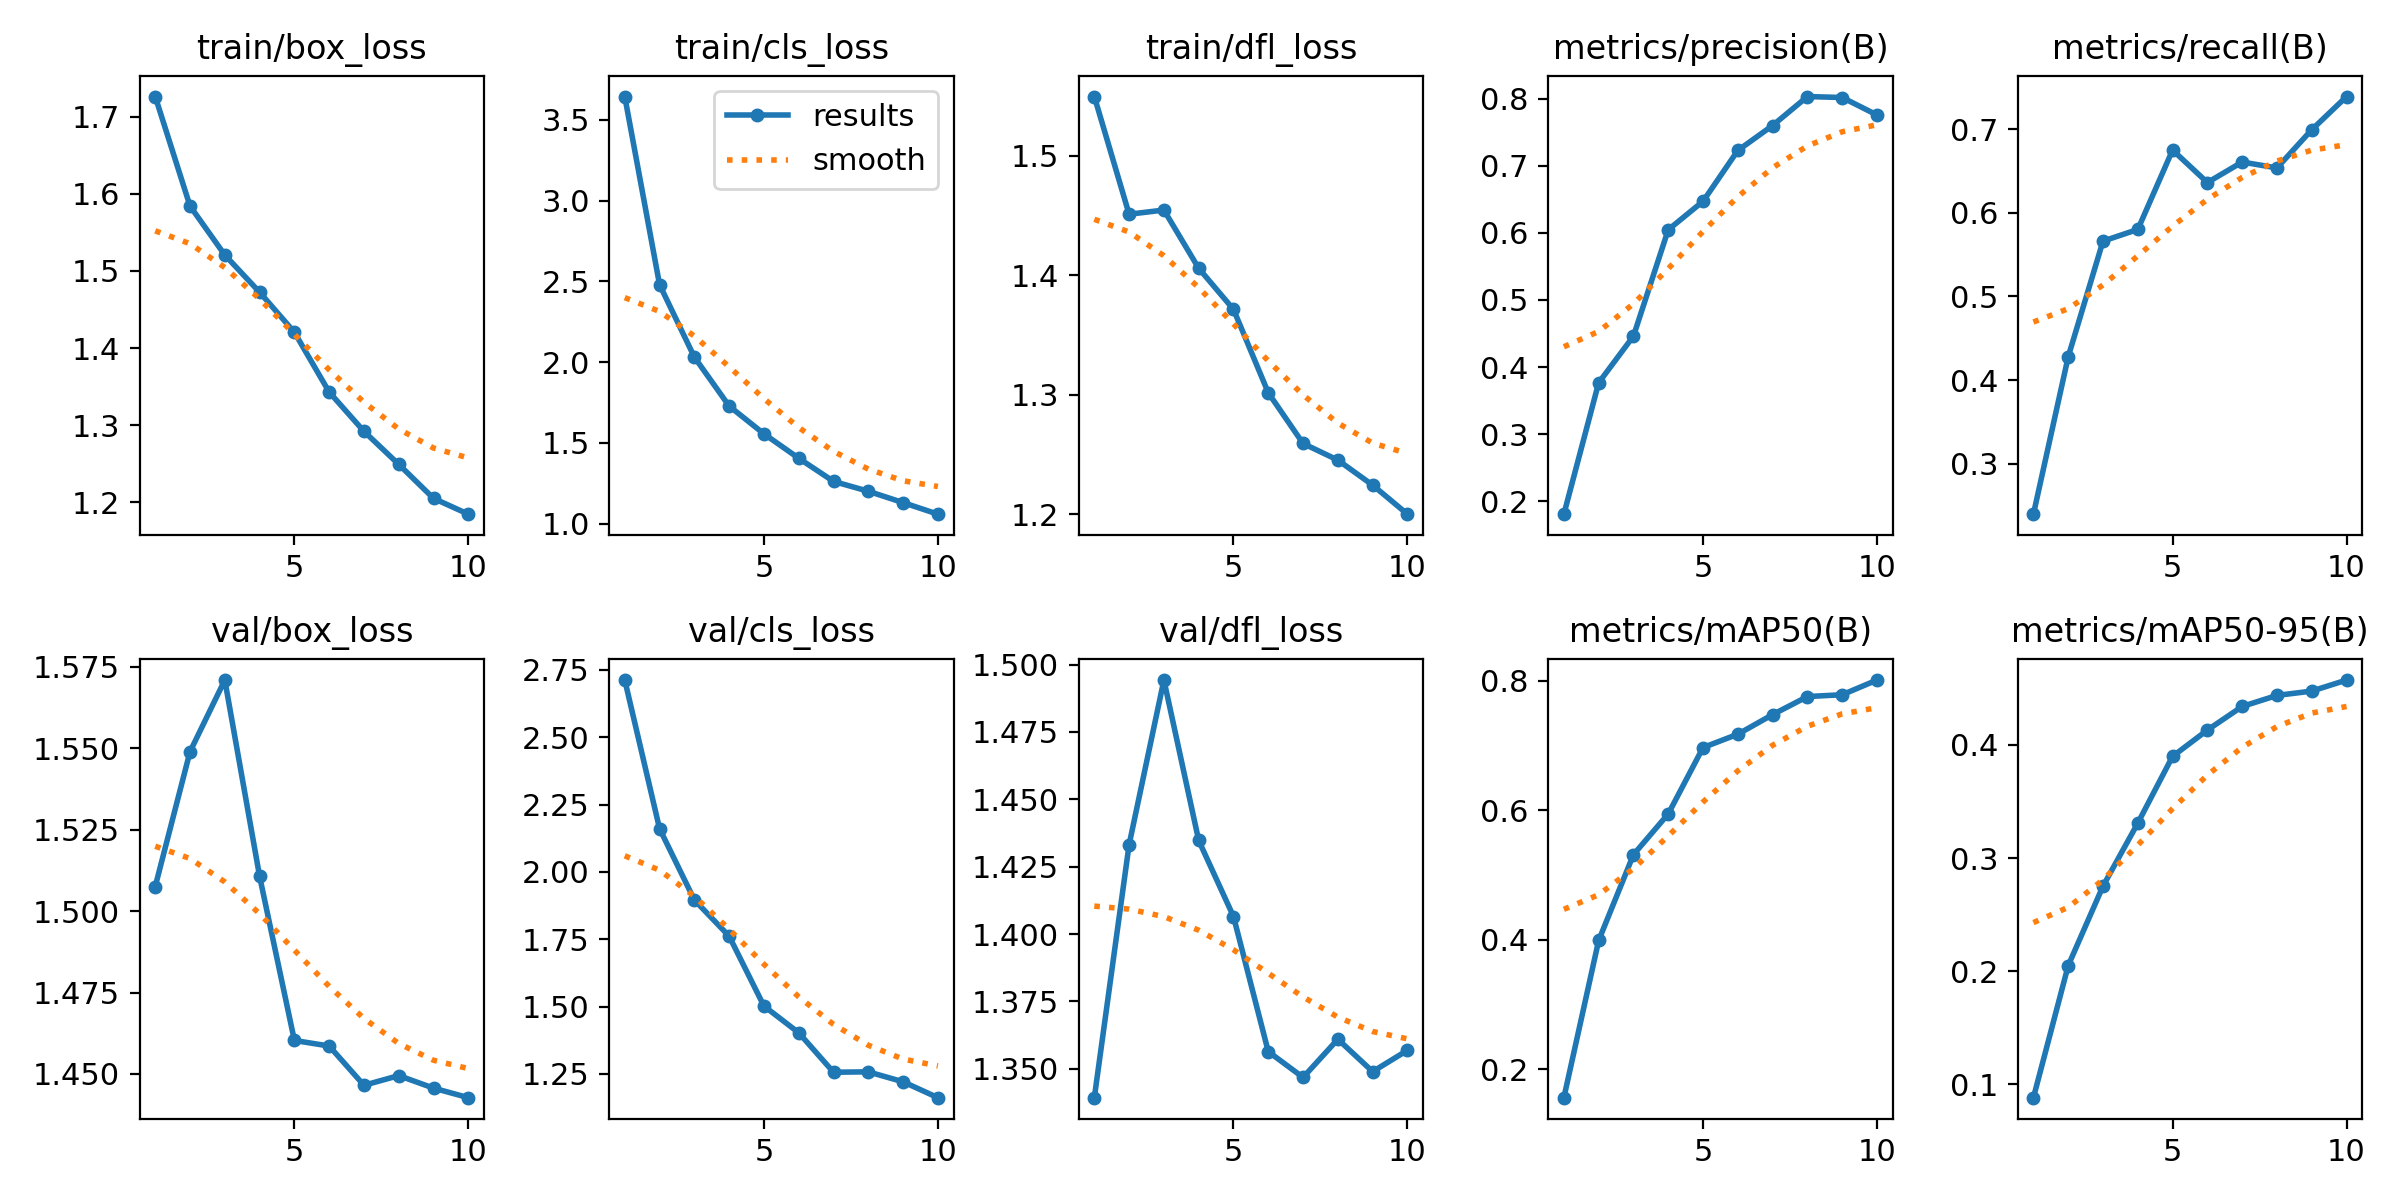

In [4]:
# O objeto 'results' guarda o diretório onde tudo foi salvo
print(f"Resultados salvos em: {results.save_dir}")

# Exibir os gráficos de perda e performance
Image(filename=f'{results.save_dir}/results.png')

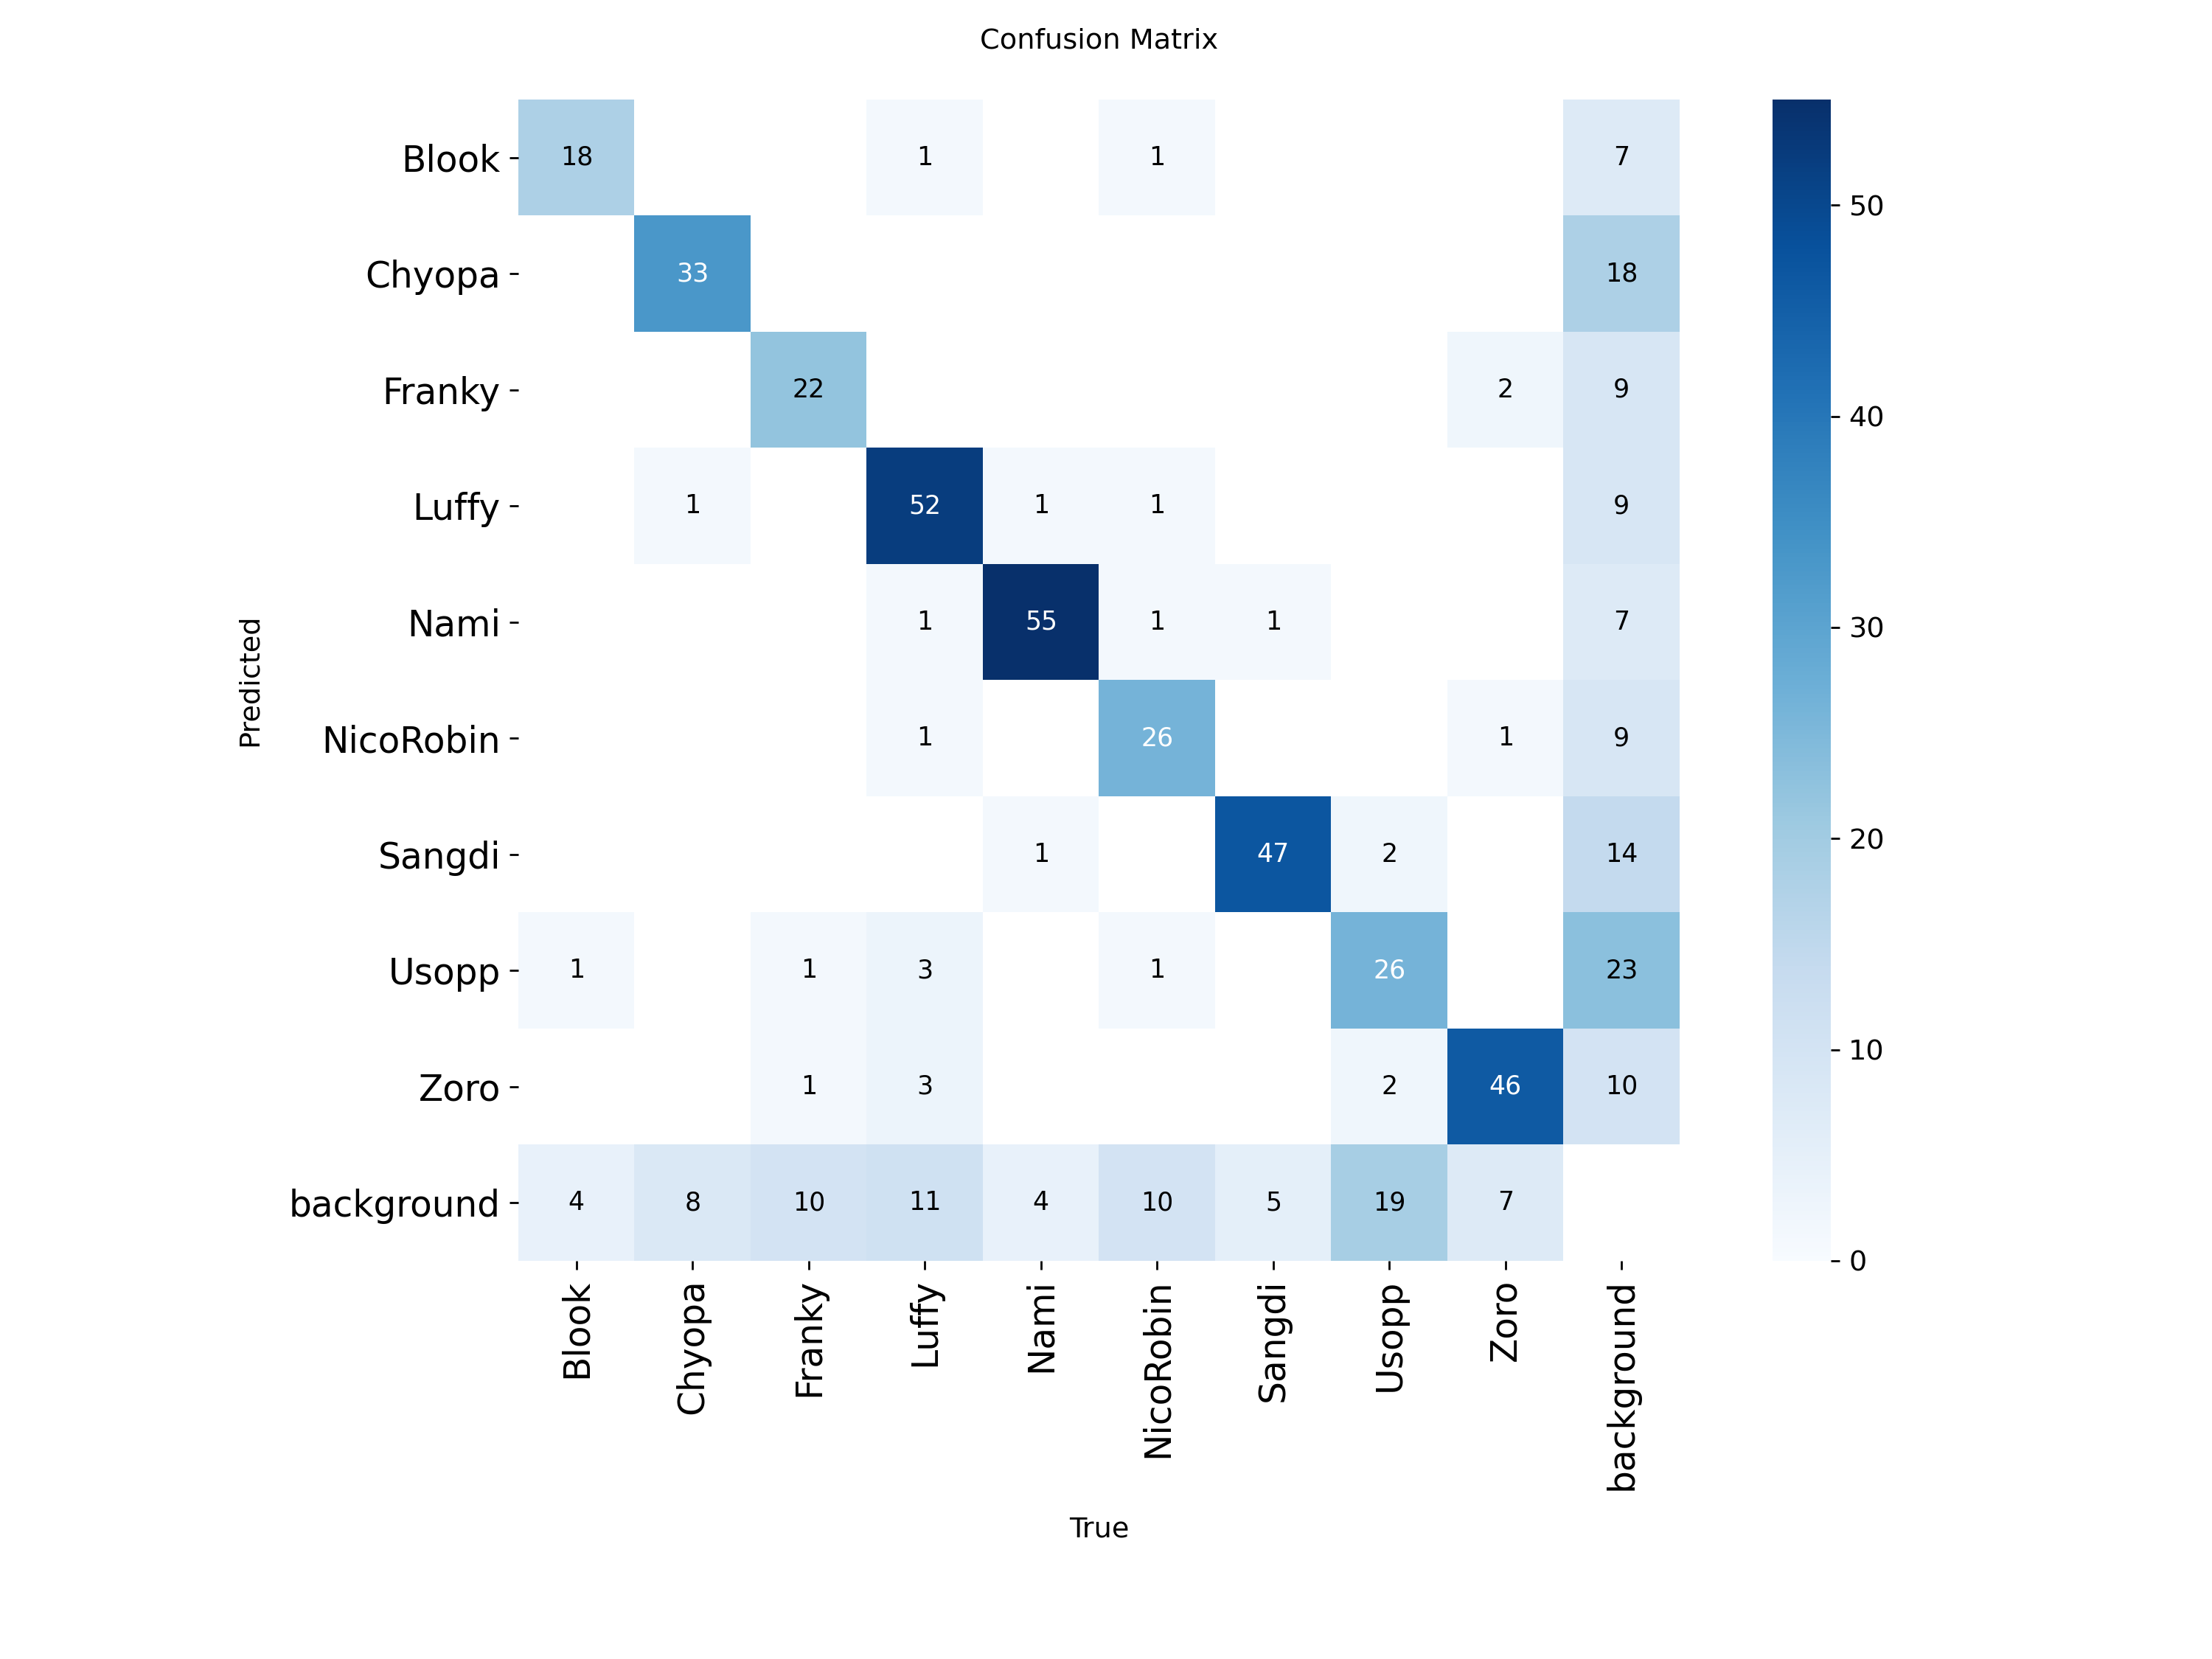

In [5]:
Image(filename=f'{results.save_dir}/confusion_matrix.png')

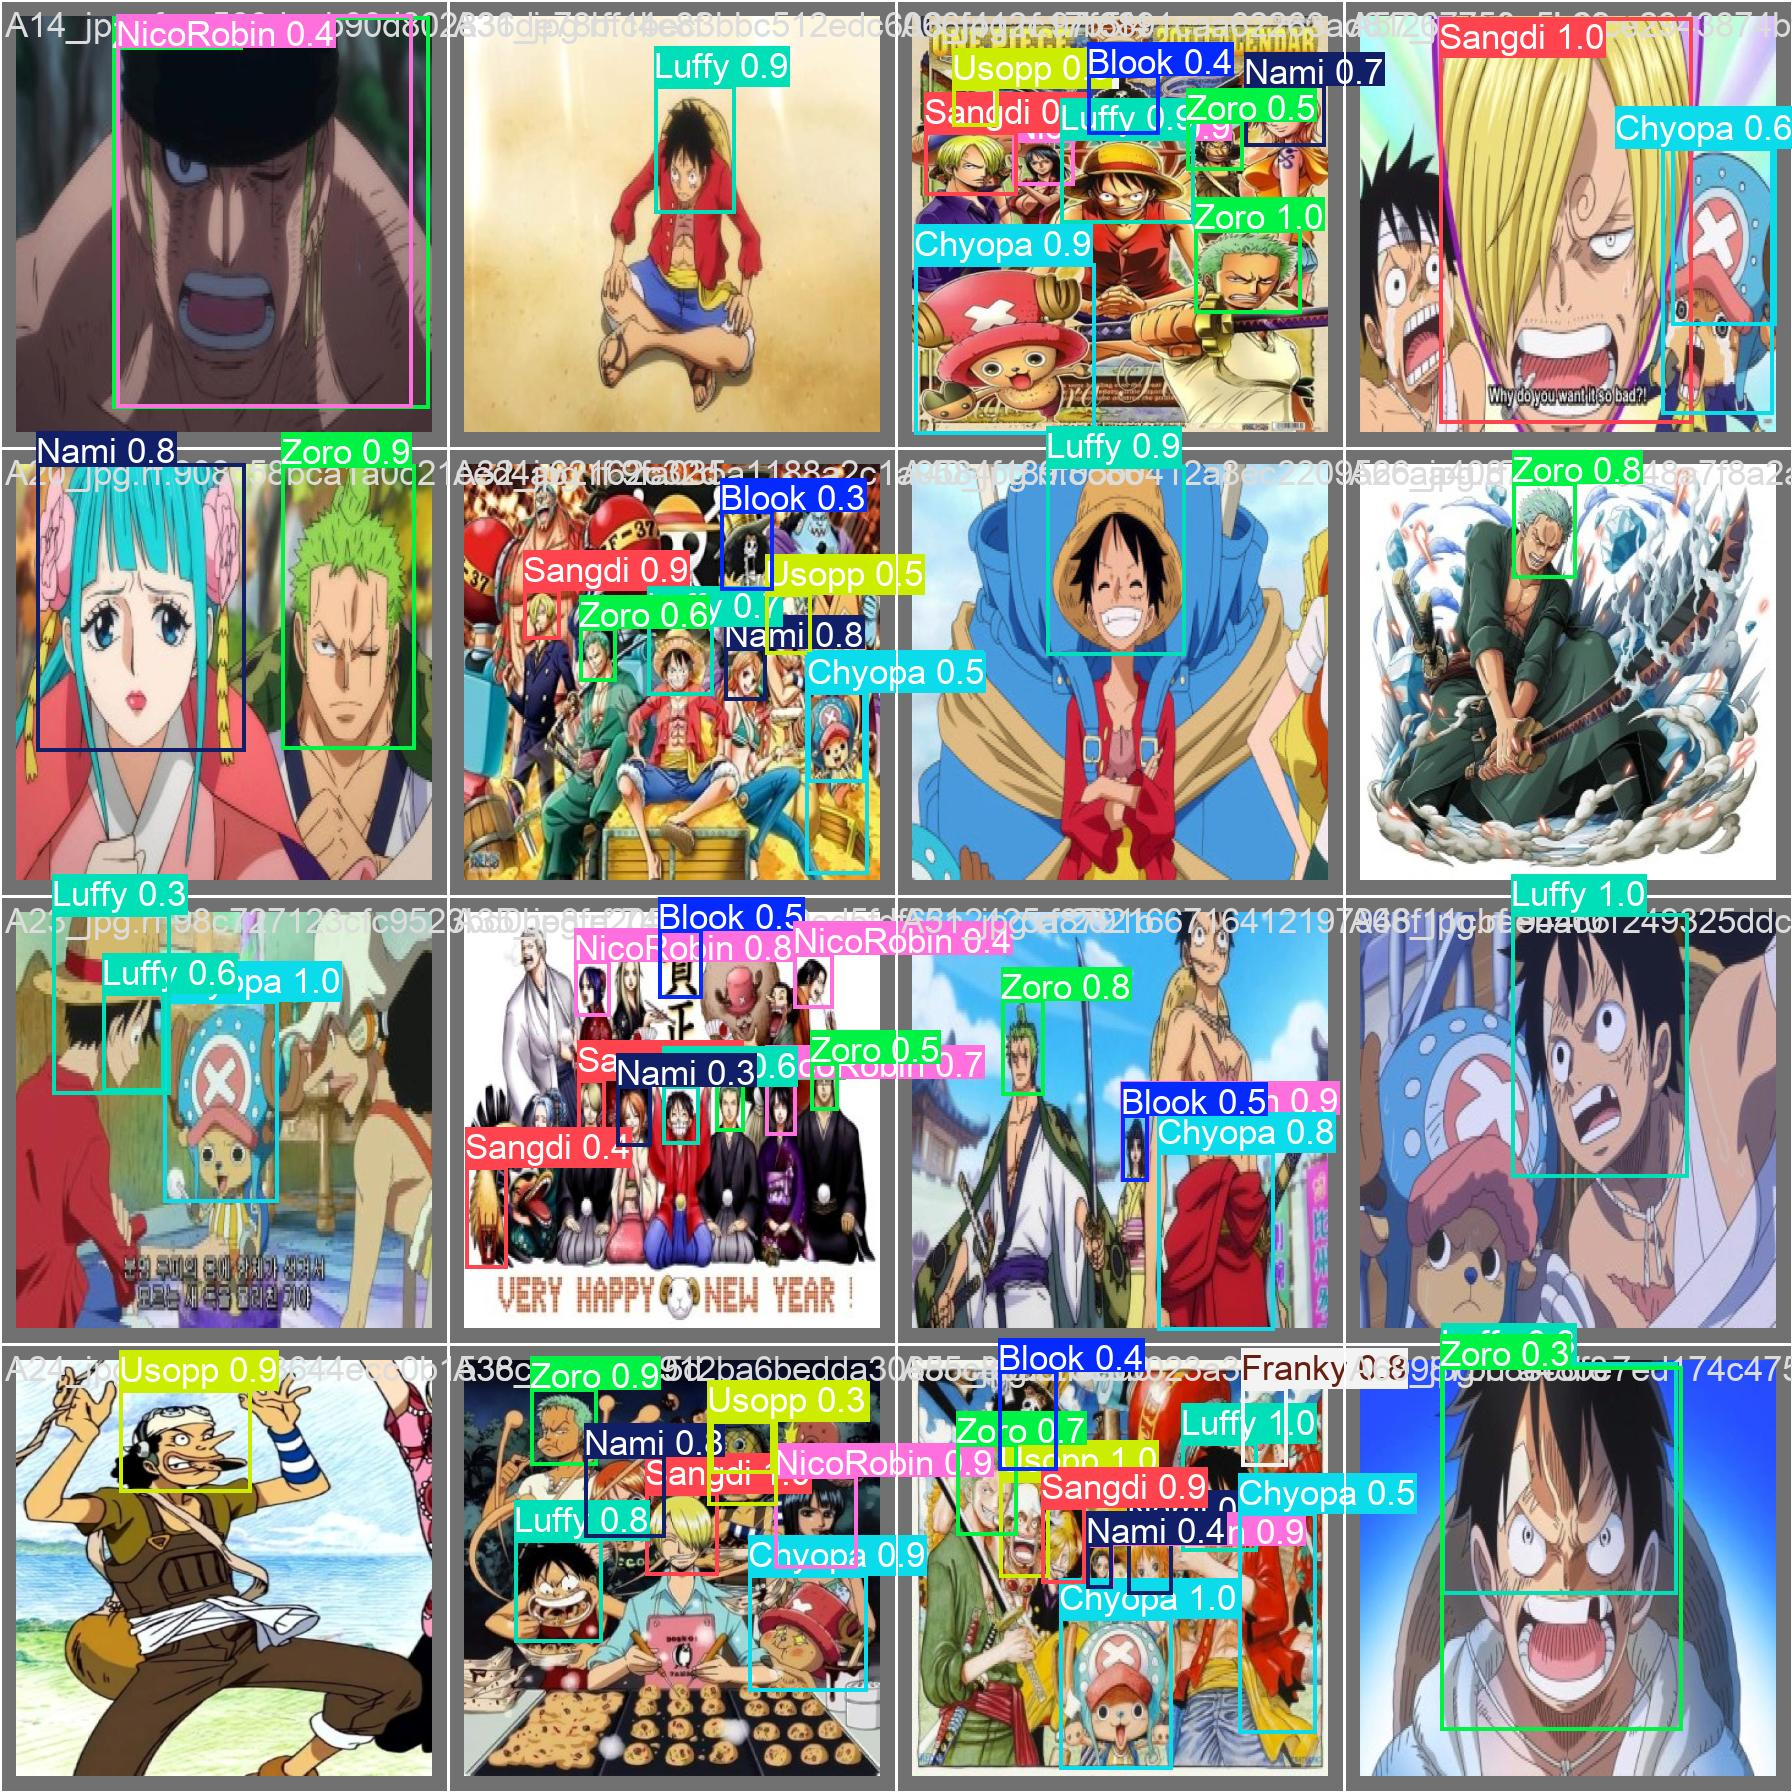

In [6]:
# O YOLO salva um lote de validação com as predições em 'val_batch0_pred.jpg'
Image(filename=f'{results.save_dir}/val_batch0_pred.jpg')